In [64]:
import numpy as np
import matplotlib.pyplot as plt

from math import factorial

In [65]:
np.random.seed(42)

## Задание №1

In [66]:
# Параметры
lambda_val = 0.1  # заявок/мс
Tk = 100          # время наблюдения (мс)
experiments = 10

results = []
all_interarrival_times = []

for exp in range(experiments):
    t = 0
    arrival_times = []
    interarrival_times = []

    while t < Tk:
        P = np.random.rand()
        delta_t = -(1/lambda_val) * np.log(P)
        t += delta_t

        if t < Tk:
            arrival_times.append(t)
            interarrival_times.append(delta_t)

    results.append(len(arrival_times))
    all_interarrival_times.extend(interarrival_times)

    print(f"Эксперимент {exp+1}: число заявок = {len(arrival_times)}")

mean_requests = np.mean(results)
mean_interarrival = np.mean(all_interarrival_times)

print("\nСреднее число заявок:", mean_requests)
print("Среднее время между заявками:", mean_interarrival)
# Среднее число заявок должно быть примерно E[N] = λT = 0.1×100 = 10
# Среднее время между заявками должно быть 1/λ = 10 мс

Эксперимент 1: число заявок = 10
Эксперимент 2: число заявок = 10
Эксперимент 3: число заявок = 9
Эксперимент 4: число заявок = 9
Эксперимент 5: число заявок = 12
Эксперимент 6: число заявок = 6
Эксперимент 7: число заявок = 10
Эксперимент 8: число заявок = 10
Эксперимент 9: число заявок = 14
Эксперимент 10: число заявок = 7

Среднее число заявок: 9.7
Среднее время между заявками: 9.806304838059464


## Задание №2

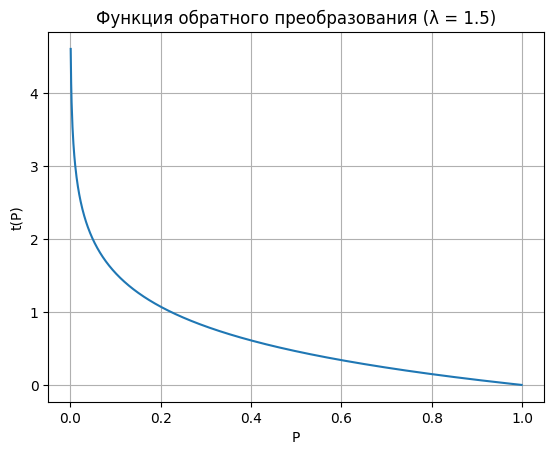

In [67]:
lambda_inv = 1.5

P = np.linspace(0.001, 0.999, 1000)
t_values = -(1/lambda_inv) * np.log(P)

plt.figure()
plt.plot(P, t_values)
plt.title("Функция обратного преобразования (λ = 1.5)")
plt.xlabel("P")
plt.ylabel("t(P)")
plt.grid()
plt.show()
# Экспоненциальное распределение

In [68]:
def generate_exponential(lambda_val, N):
    P = np.random.rand(N)
    return -(1/lambda_val) * np.log(P)

lambda_exp = 1.5
Ns = [10**3, 10**4, 10**5, 10**6]

generated_samples = {}

for N in Ns:
    samples = generate_exponential(lambda_exp, N)
    generated_samples[N] = samples
    print(f"N = {N}, среднее = {np.mean(samples):.5f}")
# Среднее значение должно стремиться к 1/λ = 1/1.5 ≈ 0.66667

N = 1000, среднее = 0.67161
N = 10000, среднее = 0.67318
N = 100000, среднее = 0.66627
N = 1000000, среднее = 0.66588


## Задание №3

N = 1000, Среднеквадратическое отклонение = 0.00636016


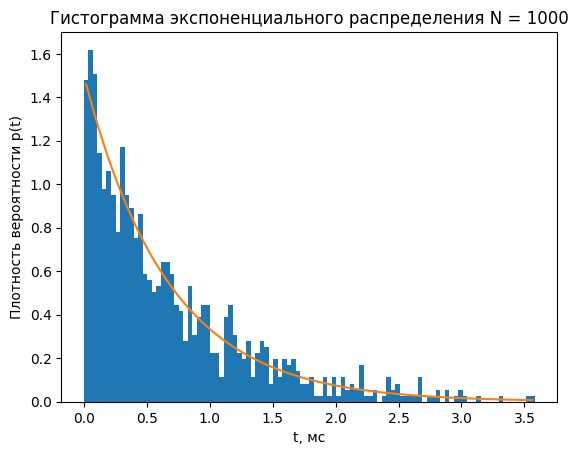

N = 10000, Среднеквадратическое отклонение = 0.00017628


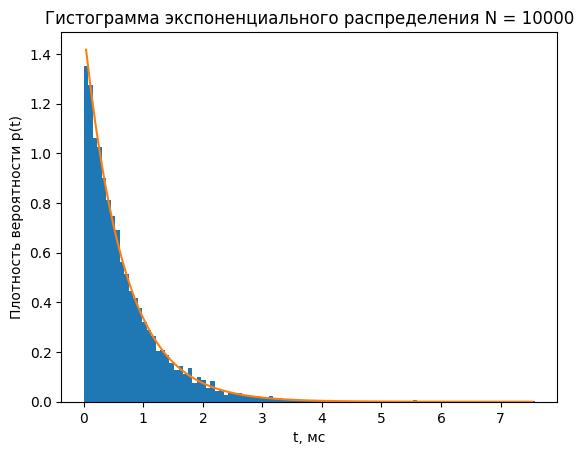

N = 100000, Среднеквадратическое отклонение = 0.00001832


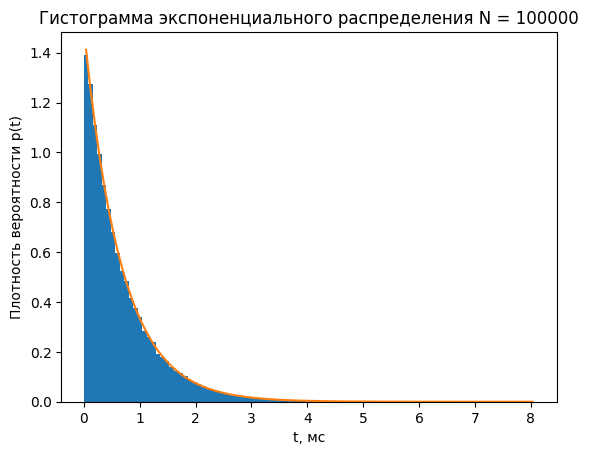

N = 1000000, Среднеквадратическое отклонение = 0.00000062


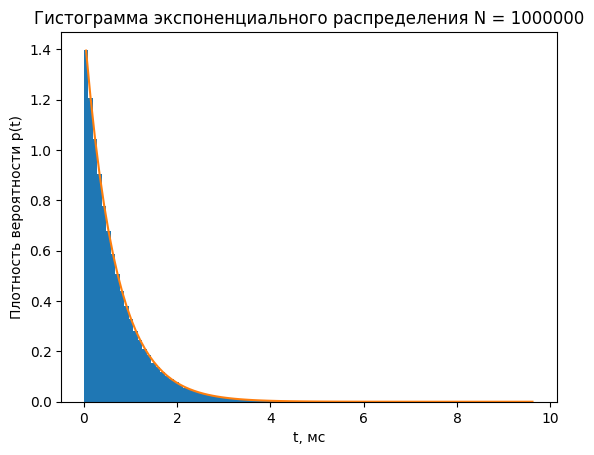

In [69]:
def theoretical_pdf(t, lambda_val):
    return lambda_val * np.exp(-lambda_val * t)

lambda_exp = 1.5

for N in Ns:
    samples = generated_samples[N]

    counts, bins = np.histogram(samples, bins=100, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pdf_values = theoretical_pdf(bin_centers, lambda_exp)

    mse = np.mean((counts - pdf_values)**2)

    print(f"N = {N}, Среднеквадратическое отклонение = {mse:.8f}")

    plt.figure()
    plt.hist(samples, bins=100, density=True)
    plt.plot(bin_centers, pdf_values)
    plt.xlabel("t, мс")
    plt.ylabel("Плотность вероятности p(t)")
    plt.title(f"Гистограмма экспоненциального распределения N = {N}")
    plt.show()

## Задание №4

In [70]:
# 1
mu1 = 1
mu2 = 0.5
N = 60

def generate_exp_process(mu, N, max_val=10):
    result = []
    while len(result) < N:
        P = np.random.rand()
        t = -(1/mu) * np.log(P)
        if 0 <= t <= max_val:  # Принимаем только если в [0, 10]
            result.append(t)
    return np.array(result)

proc1 = generate_exp_process(mu1, N)
proc2 = generate_exp_process(mu2, N)

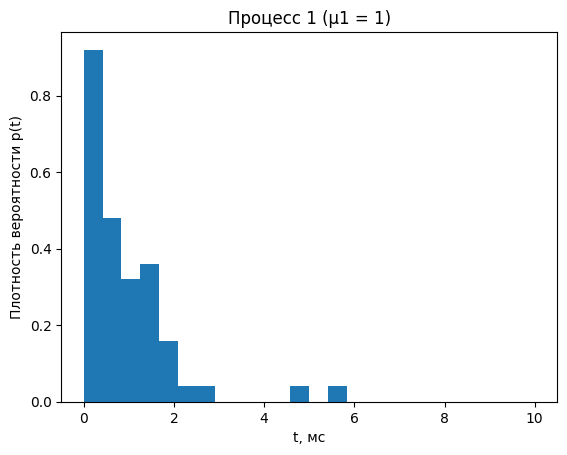

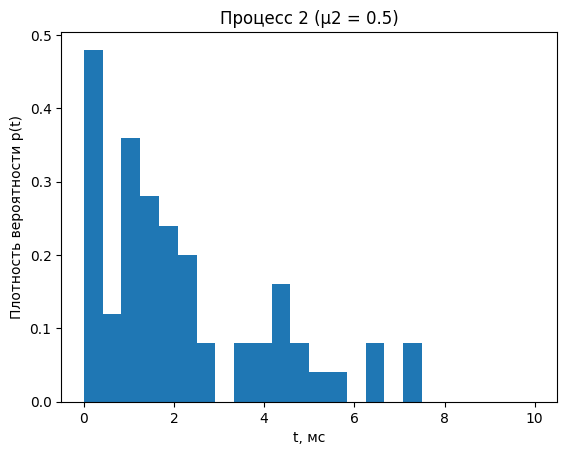

Площадь гистограммы 1: 1.0
Площадь гистограммы 2: 1.0


In [71]:
# 2
bins = 24
range_interval = (0, 10)

plt.figure()
counts1, bins1, _ = plt.hist(proc1, bins=bins, range=range_interval, density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Процесс 1 (μ1 = 1)")
plt.show()

plt.figure()
counts2, bins2, _ = plt.hist(proc2, bins=bins, range=range_interval, density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Процесс 2 (μ2 = 0.5)")
plt.show()

# Проверка площадей
area1 = np.sum(counts1 * (bins1[1]-bins1[0]))
area2 = np.sum(counts2 * (bins2[1]-bins2[0]))

print("Площадь гистограммы 1:", area1)
print("Площадь гистограммы 2:", area2)

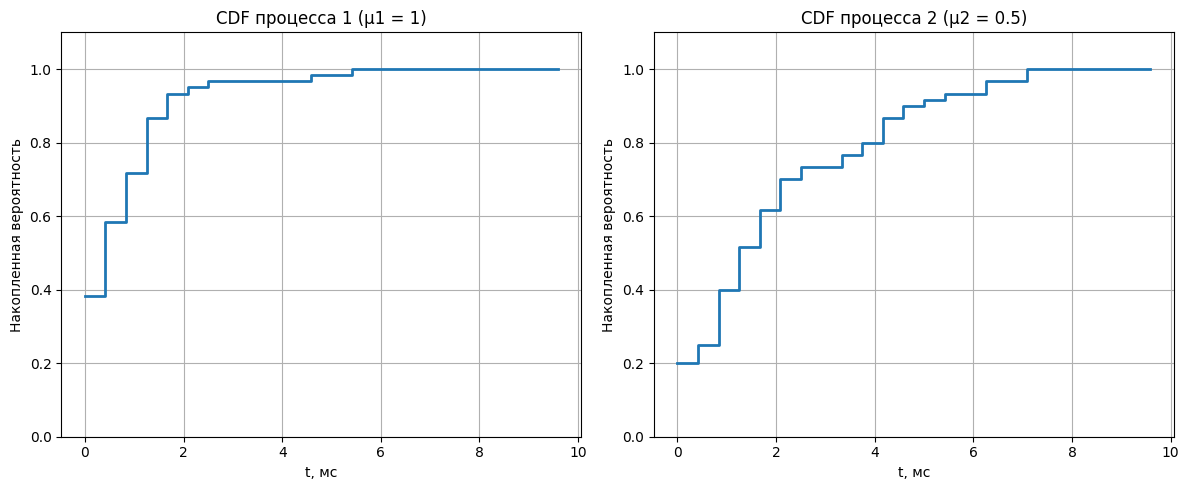

Проверка: CDF1 достигает 1.000
Проверка: CDF2 достигает 1.000


In [72]:
# 3-5
m = 60
Tp_sum = []

# строим накопленные вероятности
prob1 = counts1 * (bins1[1] - bins1[0])
prob2 = counts2 * (bins2[1] - bins2[0])

cdf1 = np.cumsum(prob1)
cdf2 = np.cumsum(prob2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.step(bins1[:-1], cdf1, where='post', linewidth=2)
plt.xlabel("t, мс")
plt.ylabel("Накопленная вероятность")
plt.title("CDF процесса 1 (μ1 = 1)")
plt.grid(True)
plt.ylim([0, 1.1])

plt.subplot(1, 2, 2)
plt.step(bins2[:-1], cdf2, where='post', linewidth=2)
plt.xlabel("t, мс")
plt.ylabel("Накопленная вероятность")
plt.title("CDF процесса 2 (μ2 = 0.5)")
plt.grid(True)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()

print(f"Проверка: CDF1 достигает {cdf1[-1]:.3f}")
print(f"Проверка: CDF2 достигает {cdf2[-1]:.3f}")


for _ in range(m):
    p1 = np.random.rand()
    p2 = np.random.rand()

    idx1 = np.searchsorted(cdf1, p1)
    idx2 = np.searchsorted(cdf2, p2)

    Tp1 = (bins1[idx1] + bins1[idx1+1]) / 2
    Tp2 = (bins2[idx2] + bins2[idx2+1]) / 2

    Tp_sum.append(Tp1 + Tp2)

Tp_sum = np.array(Tp_sum)

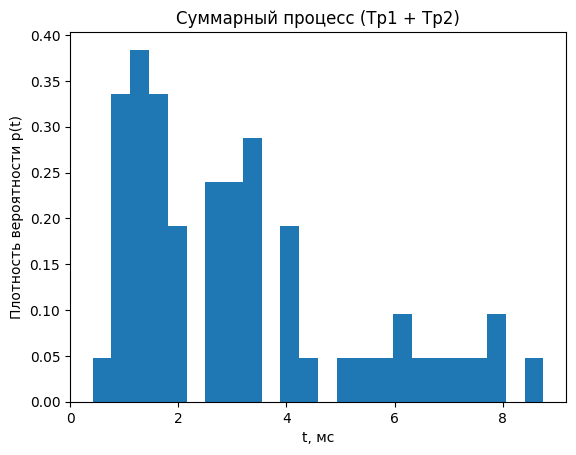

In [73]:
# 6
plt.figure()
plt.hist(Tp_sum, bins=24, density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Суммарный процесс (Tp1 + Tp2)")
plt.show()

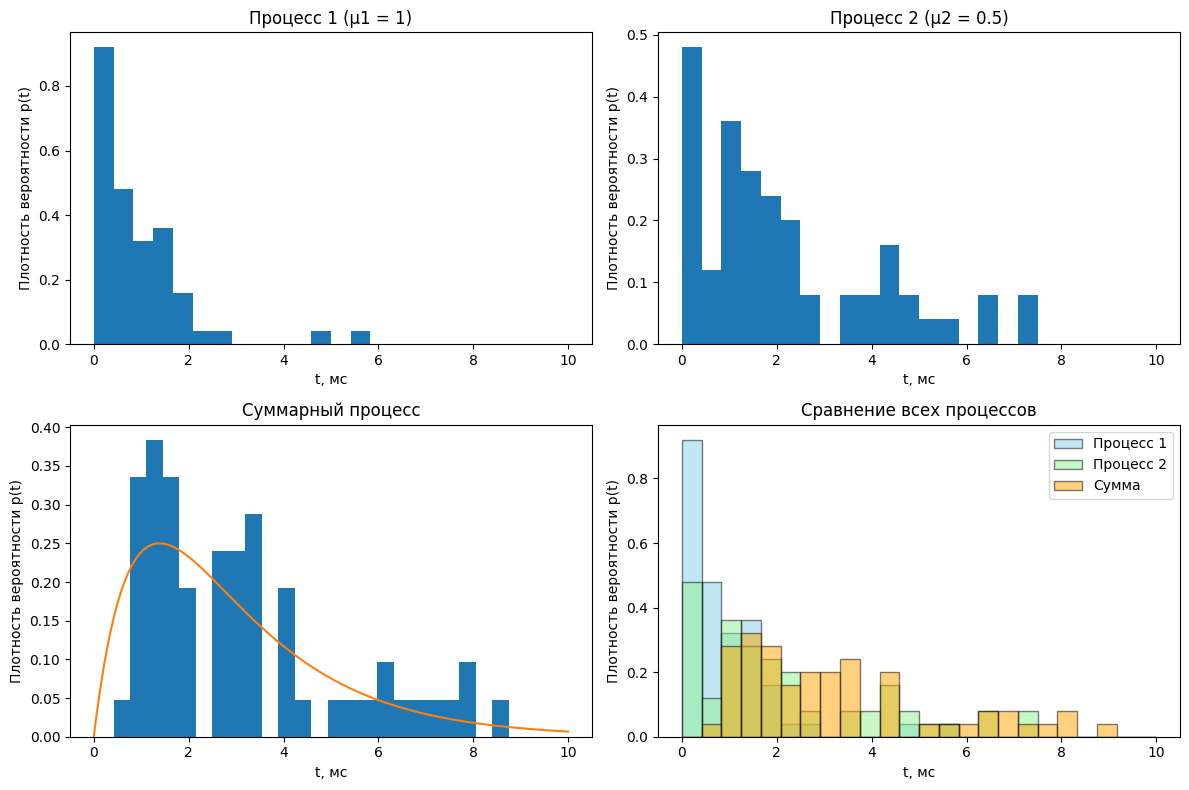

Среднее время процесса 1: 0.916 мс (теория: 1.000 мс)
Среднее время процесса 2: 2.197 мс (теория: 2.000 мс)
Среднее время суммы: 3.097 мс (теория: 3.000 мс)
Погрешность: 3.24%


In [ ]:
# 7
def hypo_pdf(t, mu1, mu2):
    return (mu1*mu2/(mu2-mu1)) * (np.exp(-mu1*t) - np.exp(-mu2*t))

t_vals = np.linspace(0, 10, 1000)

plt.figure(figsize=(12, 8))

# График 1: Процесс 1
plt.subplot(2, 2, 1)
plt.hist(proc1, bins=24, range=(0, 10), density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Процесс 1 (μ1 = 1)")

# График 2: Процесс 2
plt.subplot(2, 2, 2)
plt.hist(proc2, bins=24, range=(0, 10), density=True)
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Процесс 2 (μ2 = 0.5)")

# График 3: Сумма с теорией
plt.subplot(2, 2, 3)
plt.hist(Tp_sum, bins=24, density=True)
plt.plot(t_vals, hypo_pdf(t_vals, mu1, mu2))
plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Суммарный процесс")

# График 4: Все три процесса вместе
plt.subplot(2, 2, 4)

hist1, bins1 = np.histogram(proc1, bins=24, range=(0, 10), density=True)
hist2, bins2 = np.histogram(proc2, bins=24, range=(0, 10), density=True)
hist_sum, bins_sum = np.histogram(Tp_sum, bins=24, range=(0, 10), density=True)

bin_width = bins1[1] - bins1[0]

plt.bar(bins1[:-1], hist1, width=bin_width, align='edge',
        alpha=0.5, edgecolor='black', color='skyblue', label='Процесс 1')
plt.bar(bins2[:-1], hist2, width=bin_width, align='edge',
        alpha=0.5, edgecolor='black', color='lightgreen', label='Процесс 2')
plt.bar(bins_sum[:-1], hist_sum, width=bin_width, align='edge',
        alpha=0.5, edgecolor='black', color='orange', label='Сумма')

plt.xlabel("t, мс")
plt.ylabel("Плотность вероятности p(t)")
plt.title("Сравнение всех процессов")
plt.legend()

plt.tight_layout()
plt.show()

# Численный анализ
mean1 = np.mean(proc1)
mean2 = np.mean(proc2)
mean_sum = np.mean(Tp_sum)
theor_sum = 1/mu1 + 1/mu2

print(f"Среднее время процесса 1: {mean1:.3f} мс (теория: {1/mu1:.3f} мс)")
print(f"Среднее время процесса 2: {mean2:.3f} мс (теория: {1/mu2:.3f} мс)")
print(f"Среднее время суммы: {mean_sum:.3f} мс (теория: {theor_sum:.3f} мс)")
print(f"Погрешность: {abs(mean_sum - theor_sum)/theor_sum*100:.2f}%")

# Гипоэкспоненциальное распределение (сумма нескольких экспоненциальных распределений с разными параметрами)
